# VoxIntel — 07: Upper-Bound Intent Classifier

## Goal

Train a DistilBERT intent classifier using ground-truth transcripts only —
no audio, no ASR, nothing but the human-written `sentence` field and the
`intent` label. This answers: *if speech recognition were perfect, how well
could the system understand user intent?*

Renamed from `07_intent_classification_ground_truth` — this notebook isn't
really "train DistilBERT," it's establishing the ceiling every later
ASR-based intent result gets measured against.

## Why ground truth first

Every later intent-classification notebook needs something to be compared
against. Training on clean text first, before any ASR noise enters the
picture, isolates "how hard is intent classification, period" from "how
much does transcription quality hurt it" — those are two different
questions, and this notebook only answers the first one.

## Research hypothesis

Intent classification on clean transcripts should be substantially easier
than the ASR problem itself — SLURP's utterances are short, mostly
unambiguous commands, and DistilBERT is a strong text classifier for this
kind of task. Expect high accuracy here; the interesting research question
is how much of it survives once ASR noise gets introduced in notebook 08+.

## Settled: this model gets trained once, not three times

Two designs were on the table for 08/09: retrain a separate classifier per
transcript source, or train once here and evaluate the same fixed model
against clean / baseline-ASR / fine-tuned-ASR transcripts. Going with the
second one, for a reason beyond preference: the research question is about
*error propagation* — does noise introduced upstream break something
downstream that would otherwise work? That's only answerable if the
downstream component is held constant. Retraining per transcript source
confounds "the transcripts are noisier" with "this particular training run
converged differently," and it also doesn't match production reality,
where you don't get to pick a different NLU model depending on which ASR
engine produced the input.

The retrain-per-source idea isn't wasted, though — it's a legitimate,
different experiment (does training on noisy data build robustness?) that
fits naturally as a later robustness-training notebook, not as 08/09.

## What this notebook deliberately does not do

No ASR transcripts (baseline or fine-tuned), no error taxonomy, no
quantization, no deployment. Just the strongest practical intent
classifier trainable on clean text, with enough saved (probabilities,
top-3 predictions, calibration) that notebook 08 can reuse it fully
without retraining or rerunning inference from scratch.


Make `src` importable.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\ACER\OneDrive\Desktop\VoxIntel


## Imports

In [3]:
import json
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from transformers import (
    AutoTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

from src.data import SLURPDataset
from src.utils.text import clean_transcript

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

c:\Users\ACER\anaconda3\envs\torch26\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

In [4]:
ROOT_DIR = r"C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\raw\slurp"
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 64

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / "distilbert_intent"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_DIR = PROJECT_ROOT / "reports"

BATCH_SIZE = 32
LR = 2e-5
NUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## Load train and validation splits

Ground truth only — `SLURPDataset` already carries `sentence` and `intent`
for every recording; audio isn't even touched here.


In [5]:
train_set = SLURPDataset(split="train", root_dir=ROOT_DIR)
val_set = SLURPDataset(split="validation", root_dir=ROOT_DIR)

print(train_set.summary())
print(val_set.summary())

{'split': 'train', 'n_samples': 50628, 'n_unique_intents': 91, 'n_missing_audio': 0, 'n_missing_transcript': 0, 'n_missing_intent': 0}
{'split': 'validation', 'n_samples': 8690, 'n_unique_intents': 71, 'n_missing_audio': 0, 'n_missing_transcript': 0, 'n_missing_intent': 0}


## Dataset preparation, with deduplication

`SLURPDataset` yields one row per *recording*, not per *sentence* — the
same sentence read by multiple speakers appears multiple times with
identical text and identical intent, just different audio files. For a
text-only classifier that's not extra training signal, it's just some
sentences getting seen more often purely because more people happened to
record them. Deduplicating by `slurp_id` (falling back to the
`sentence`+`intent` pair if `id` is missing) keeps each unique utterance
exactly once.


In [6]:
def to_dedup_dataframe(dataset):
    rows = []
    seen = set()

    for sample in dataset:
        key = sample["id"] if sample["id"] is not None else (sample["transcript"], sample["intent"])
        if key in seen:
            continue
        seen.add(key)

        if not sample["transcript"] or not sample["intent"]:
            continue

        rows.append({
            "sentence": sample["transcript"],
            "intent": sample["intent"],
            "scenario": sample["scenario"],
        })

    return pd.DataFrame(rows)


train_df = to_dedup_dataframe(train_set)
val_df = to_dedup_dataframe(val_set)

print(f"train: {len(train_set)} recordings -> {len(train_df)} unique sentences")
print(f"validation: {len(val_set)} recordings -> {len(val_df)} unique sentences")


train: 50628 recordings -> 11514 unique sentences
validation: 8690 recordings -> 2033 unique sentences


## Dataset analysis

Quick verification, not a repeat of notebook 01's full audit — just
confirming the numbers going into training look sane, plus one check that
matters specifically for a classifier: every validation intent needs to
have shown up in training, or the model has no way to ever predict it
correctly regardless of transcript quality.


In [7]:
print(f"Train sentences: {len(train_df)}")
print(f"Validation sentences: {len(val_df)}")
print(f"Train unique intents: {train_df['intent'].nunique()}")
print(f"Validation unique intents: {val_df['intent'].nunique()}")

train_intents = set(train_df["intent"])
val_intents = set(val_df["intent"])
unseen_in_train = val_intents - train_intents

if unseen_in_train:
    print(f"\nWARNING: {len(unseen_in_train)} validation intents never appear in train:")
    print(sorted(unseen_in_train))
else:
    print("\nAll validation intents are present in train. Good.")


Train sentences: 11514
Validation sentences: 2033
Train unique intents: 91
Validation unique intents: 71

['likeness']


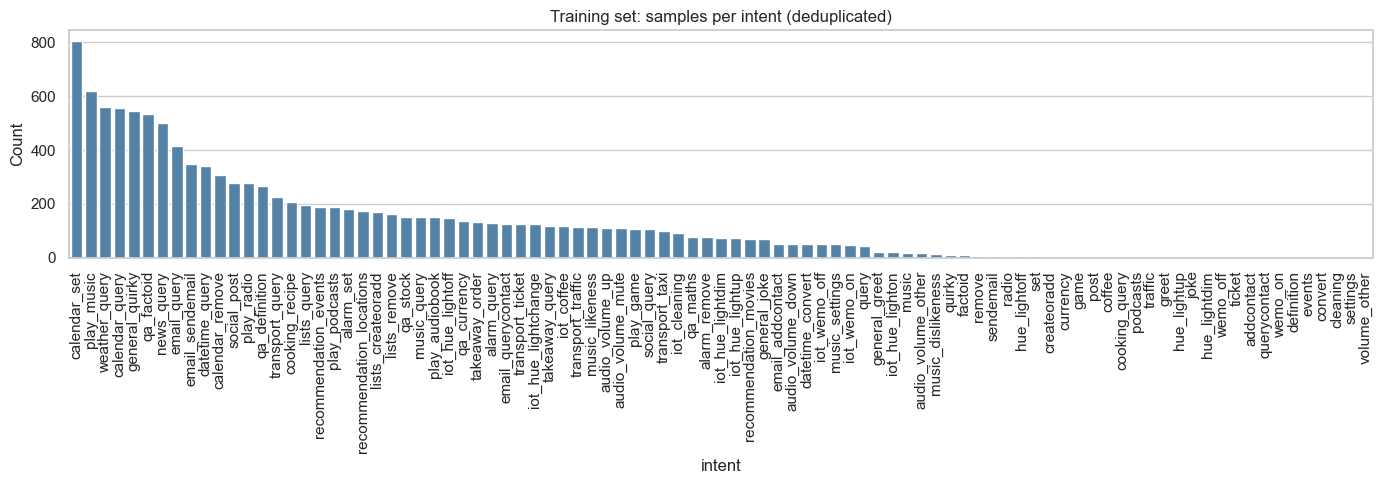

Largest class: calendar_set (804)
Smallest class: ticket (1)


In [8]:
intent_counts = train_df["intent"].value_counts()

plt.figure(figsize=(14, 5))
sns.barplot(x=intent_counts.index, y=intent_counts.values, color="steelblue")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.title("Training set: samples per intent (deduplicated)")
plt.tight_layout()
plt.show()

print(f"Largest class: {intent_counts.idxmax()} ({intent_counts.max()})")
print(f"Smallest class: {intent_counts.idxmin()} ({intent_counts.min()})")


## Label encoding

Saved to `artifacts/` since both `08` and `09` will need to load the same
mapping to make sense of this model's predictions without retraining.


In [9]:
unique_intents = sorted(train_df["intent"].unique())
label2id = {intent: i for i, intent in enumerate(unique_intents)}
id2label = {i: intent for intent, i in label2id.items()}

train_df["label"] = train_df["intent"].map(label2id)
val_df["label"] = val_df["intent"].map(label2id)

n_labels_missing_in_val = val_df["label"].isna().sum()
if n_labels_missing_in_val:
    print(f"Dropping {n_labels_missing_in_val} validation rows with intents unseen in train")
    val_df = val_df.dropna(subset=["label"])
val_df["label"] = val_df["label"].astype(int)

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
with open(ARTIFACTS_DIR / "label2id.json", "w") as f:
    json.dump(label2id, f, indent=2)
with open(ARTIFACTS_DIR / "id2label.json", "w") as f:
    json.dump(id2label, f, indent=2)

print(f"{len(label2id)} labels saved to {ARTIFACTS_DIR}")


Dropping 1 validation rows with intents unseen in train
91 labels saved to c:\Users\ACER\OneDrive\Desktop\VoxIntel\artifacts


## Tokenization

Using `clean_transcript()` rather than the more aggressive `normalize_text()`
used for WER scoring elsewhere in this project — that one strips
punctuation, which is real signal for a subword tokenizer. DistilBERT-uncased
already handles casing on its own.

`MAX_LENGTH` is checked empirically below rather than assumed.


In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_df["clean_sentence"] = train_df["sentence"].apply(clean_transcript)
val_df["clean_sentence"] = val_df["sentence"].apply(clean_transcript)

token_lengths = train_df["clean_sentence"].apply(lambda t: len(tokenizer.encode(t)))
print(f"Token length -- min: {token_lengths.min()}, median: {token_lengths.median()}, "
      f"mean: {token_lengths.mean():.1f}, max: {token_lengths.max()}, "
      f"99th percentile: {token_lengths.quantile(0.99):.0f}")

pct_over_64 = (token_lengths > 64).mean() * 100
pct_over_128 = (token_lengths > 128).mean() * 100
print(f"Percent of sentences over 64 tokens: {pct_over_64:.2f}%")
print(f"Percent of sentences over 128 tokens: {pct_over_128:.2f}%")


Token length -- min: 3, median: 9.0, mean: 9.4, max: 39, 99th percentile: 20
Percent of sentences over 64 tokens: 0.00%
Percent of sentences over 128 tokens: 0.00%


If the percentage over 64 tokens above is negligible (well under 1%),
`MAX_LENGTH = 64` in the config cell is the right call and truncation
barely matters. If it's notably higher, bump `MAX_LENGTH` to 128 and
re-run from the config cell.


## Convert to Hugging Face Datasets and tokenize

In [11]:
train_hf = Dataset.from_pandas(train_df[["clean_sentence", "label"]], preserve_index=False)
val_hf = Dataset.from_pandas(val_df[["clean_sentence", "label"]], preserve_index=False)


def tokenize_function(batch):
    return tokenizer(
        batch["clean_sentence"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )


train_dataset = train_hf.map(tokenize_function, batched=True, remove_columns=["clean_sentence"])
val_dataset = val_hf.map(tokenize_function, batched=True, remove_columns=["clean_sentence"])

train_dataset, val_dataset


Map: 100%|██████████| 2032/2032 [00:00<00:00, 20899.16 examples/s]


(Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 11514
 }),
 Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 2032
 }))

## Model

In [12]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
)
model.to(DEVICE)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 500.54it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## Training

DistilBERT is a small model (66M parameters) and this is text-only, no
audio -- expect this to be comfortably lightweight even on the same
hardware that struggled with Wav2Vec2 fine-tuning. No gradient
checkpointing or memory tricks needed here.


In [13]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    accuracy = accuracy_score(labels, preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision_macro,
        "recall": recall_macro,
        "f1": f1_macro,
    }


training_args = TrainingArguments(
    output_dir=str(MODEL_OUTPUT_DIR),
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    num_train_epochs=NUM_EPOCHS,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

In [14]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.863421,1.544686,0.687992,0.420166,0.393436,0.370902
2,1.218086,0.886987,0.812500,0.601676,0.578257,0.571228
3,0.725232,0.703187,0.842028,0.629058,0.632791,0.625101
4,0.504753,0.634142,0.858760,0.674786,0.679320,0.672010
5,0.378062,0.603884,0.863681,0.687823,0.688881,0.685496
6,0.294769,0.602860,0.865650,0.686828,0.702247,0.692337
7,0.246027,0.603178,0.866634,0.684338,0.704609,0.691612
8,0.211545,0.612799,0.865157,0.697216,0.709679,0.697218
9,0.188971,0.611257,0.867126,0.700979,0.711470,0.702169
10,0.174152,0.611280,0.868110,0.700747,0.717704,0.706673


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.14it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3600, training_loss=0.6805016549428304, metrics={'train_runtime': 793.3525, 'train_samples_per_second': 145.131, 'train_steps_per_second': 4.538, 'total_flos': 1909563069104640.0, 'train_loss': 0.6805016549428304, 'epoch': 10.0})

## Evaluation

In [15]:
final_metrics = trainer.evaluate()
final_metrics

{'eval_loss': 0.6112800240516663,
 'eval_accuracy': 0.8681102362204725,
 'eval_precision': 0.7007466471298086,
 'eval_recall': 0.7177041999743948,
 'eval_f1': 0.7066731464150999,
 'eval_runtime': 3.8345,
 'eval_samples_per_second': 529.928,
 'eval_steps_per_second': 16.691,
 'epoch': 10.0}

In [19]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [21]:
predictions_output = trainer.predict(val_dataset)
pred_labels = predictions_output.predictions.argmax(-1)
true_labels = predictions_output.label_ids

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    true_labels, pred_labels, average="weighted", zero_division=0
)

all_label_ids = sorted(id2label.keys())

report_dict = classification_report(
    true_labels,
    pred_labels,
    labels=all_label_ids,
    target_names=[id2label[i] for i in all_label_ids],
    output_dict=True,
    zero_division=0,
)

print(f"Accuracy       : {final_metrics['eval_accuracy']:.4f}")
print(f"Macro Precision: {final_metrics['eval_precision']:.4f}")
print(f"Macro Recall   : {final_metrics['eval_recall']:.4f}")
print(f"Macro F1       : {final_metrics['eval_f1']:.4f}")
print(f"Weighted F1    : {f1_weighted:.4f}")

Accuracy       : 0.8681
Macro Precision: 0.7007
Macro Recall   : 0.7177
Macro F1       : 0.7067
Weighted F1    : 0.8608


## Per-intent and per-scenario breakdown

Per-intent because that's the direct question ("which intents are
hardest"). Per-scenario nearly for free once per-intent exists, and it
pairs with the same breakdown already done for ASR in notebooks 04 and 06.


In [22]:
val_df = val_df.reset_index(drop=True)
val_df["predicted_label"] = pred_labels
val_df["predicted_intent"] = val_df["predicted_label"].map(id2label)
val_df["correct"] = val_df["intent"] == val_df["predicted_intent"]

probs = torch.softmax(torch.tensor(predictions_output.predictions), dim=-1).numpy()
val_df["confidence"] = probs[np.arange(len(probs)), pred_labels]

top3_indices = np.argsort(-probs, axis=1)[:, :3]
val_df["top3_intents"] = [
    [id2label[i] for i in row] for row in top3_indices
]
val_df["top3_correct"] = [
    true_intent in top3 for true_intent, top3 in zip(val_df["intent"], val_df["top3_intents"])
]

top1_acc = val_df["correct"].mean()
top3_acc = val_df["top3_correct"].mean()
print(f"Top-1 accuracy: {top1_acc:.4f}")
print(f"Top-3 accuracy: {top3_acc:.4f}")
print(f"Gap: {top3_acc - top1_acc:.4f} -- how much accuracy is \"almost right\" vs genuinely wrong")

np.save(REPORTS_DIR / "ground_truth_val_probabilities.npy", probs)
print(f"Full probability array saved to {REPORTS_DIR / 'ground_truth_val_probabilities.npy'}")


Top-1 accuracy: 0.8681
Top-3 accuracy: 0.9483
Gap: 0.0802 -- how much accuracy is "almost right" vs genuinely wrong
Full probability array saved to c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\ground_truth_val_probabilities.npy


Saving the full probability array (not just top-3) means notebook 08
can compute calibration, top-k accuracy, or anything else against this
exact model's ground-truth-transcript predictions without rerunning
inference — same reasoning as caching ASR predictions to CSV in earlier
notebooks.


In [23]:
per_intent = val_df.groupby("intent").agg(
    accuracy=("correct", "mean"),
    count=("correct", "size"),
).sort_values("accuracy")

print("Hardest intents (lowest accuracy):")
print(per_intent.head(15))


Hardest intents (lowest accuracy):
                   accuracy  count
intent                            
cleaning           0.000000      1
general_greet      0.000000      1
quirky             0.000000      2
greet              0.000000      1
hue_lightoff       0.000000      1
cooking_query      0.000000      2
query              0.000000     10
hue_lightup        0.000000      1
factoid            0.000000      1
post               0.000000      1
podcasts           0.000000      2
music              0.000000      7
music_dislikeness  0.000000      2
set                0.000000      2
general_quirky     0.543689    103


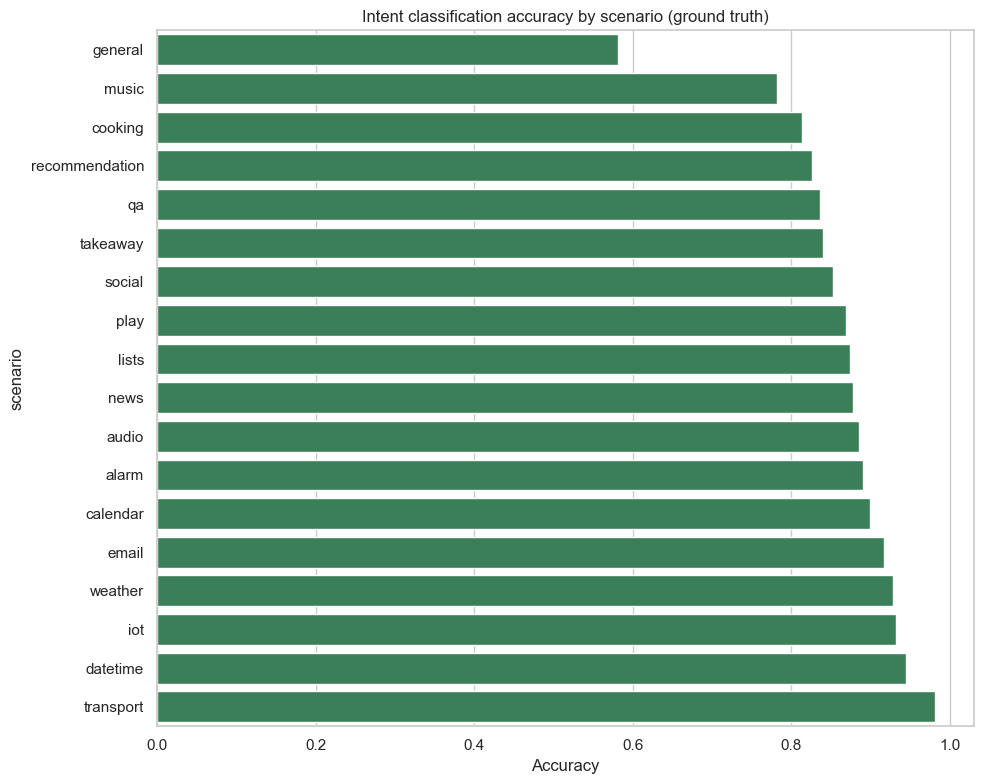

In [24]:
per_scenario = val_df.groupby("scenario").agg(
    accuracy=("correct", "mean"),
    count=("correct", "size"),
).sort_values("accuracy")

plt.figure(figsize=(10, 8))
sns.barplot(x=per_scenario["accuracy"], y=per_scenario.index, color="seagreen")
plt.xlabel("Accuracy")
plt.title("Intent classification accuracy by scenario (ground truth)")
plt.tight_layout()
plt.show()


## Confidence calibration

A model can be accurate on average while still being poorly calibrated --
confidently wrong on some examples, unconfidently right on others. This
matters for notebook 08's eventual question of whether ASR errors also
degrade classifier confidence, not just classifier accuracy: that
comparison only means something if this notebook establishes what
well-calibrated (or not) looks like on clean input first.

Reliability diagram: bin predictions by confidence, plot each bin's actual
accuracy against its average confidence. A perfectly calibrated model sits
on the diagonal. Expected Calibration Error (ECE) summarizes the gap as a
single number -- the size-weighted average distance between confidence and
accuracy across bins.


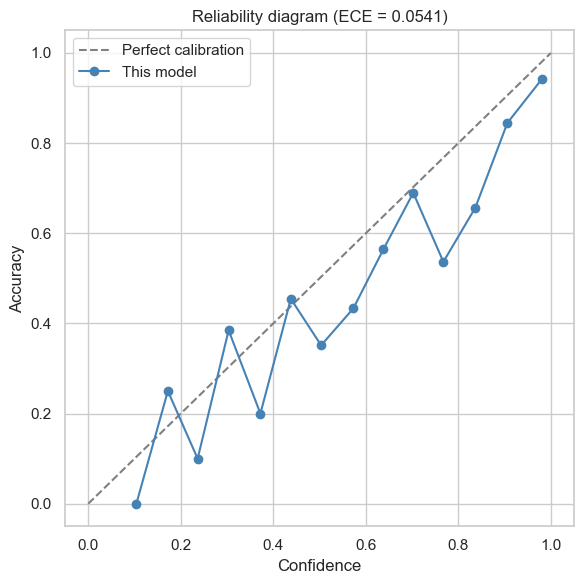

Expected Calibration Error: 0.0541


In [25]:
def compute_calibration(confidences, correct, n_bins=15):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_accuracy = []
    bin_confidence = []
    bin_count = []

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences >= lo) & (confidences < hi) if i < n_bins - 1 else (confidences >= lo) & (confidences <= hi)
        if mask.sum() == 0:
            continue
        bin_accuracy.append(correct[mask].mean())
        bin_confidence.append(confidences[mask].mean())
        bin_count.append(mask.sum())

    bin_accuracy = np.array(bin_accuracy)
    bin_confidence = np.array(bin_confidence)
    bin_count = np.array(bin_count)

    ece = np.sum(bin_count / bin_count.sum() * np.abs(bin_accuracy - bin_confidence))
    return bin_confidence, bin_accuracy, bin_count, ece


bin_conf, bin_acc, bin_count, ece = compute_calibration(
    val_df["confidence"].values, val_df["correct"].values
)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.plot(bin_conf, bin_acc, marker="o", color="steelblue", label="This model")
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title(f"Reliability diagram (ECE = {ece:.4f})")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "calibration_ground_truth.png", dpi=150)
plt.show()

print(f"Expected Calibration Error: {ece:.4f}")


## Class imbalance vs. per-class F1

Notebook 01 found a 2,415x imbalance ratio between the largest and
smallest intent class. This checks whether that imbalance is actually
hurting rare classes here, rather than just assuming it does.


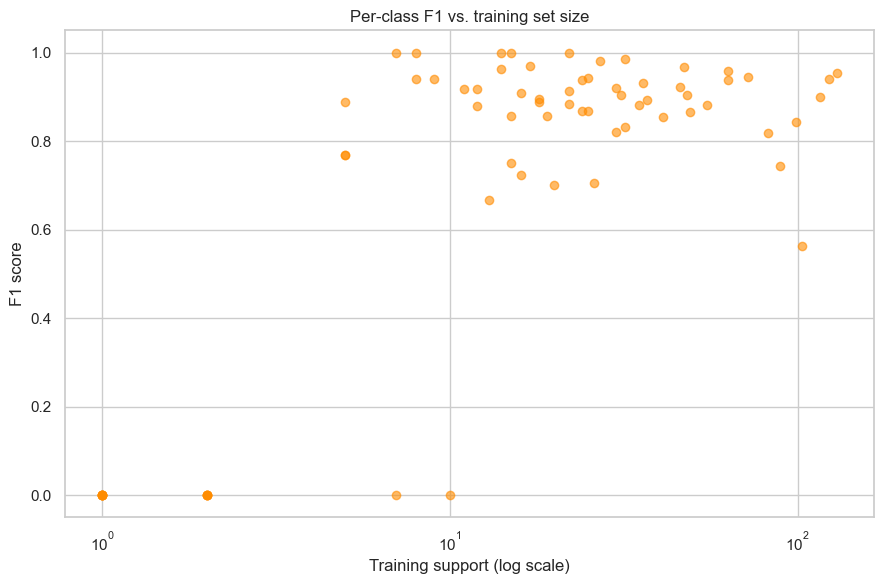

Correlation between class support and F1: 0.547


In [26]:
class_report_df = pd.DataFrame(report_dict).T
class_report_df = class_report_df.drop(["accuracy", "macro avg", "weighted avg"], errors="ignore")
class_report_df["support"] = class_report_df["support"].astype(float)

plt.figure(figsize=(9, 6))
plt.scatter(class_report_df["support"], class_report_df["f1-score"], alpha=0.6, color="darkorange")
plt.xscale("log")
plt.xlabel("Training support (log scale)")
plt.ylabel("F1 score")
plt.title("Per-class F1 vs. training set size")
plt.tight_layout()
plt.show()

correlation = class_report_df["support"].corr(class_report_df["f1-score"])
print(f"Correlation between class support and F1: {correlation:.3f}")


## Confusion matrix

A full matrix across ~90 intents would be unreadable as a single heatmap,
so this plots only the top 25 most frequent intents (covering the bulk of
validation samples), and separately surfaces the specific confused pairs
as a readable table -- that answers "which intents get mixed up" more
directly than a giant heatmap would anyway.


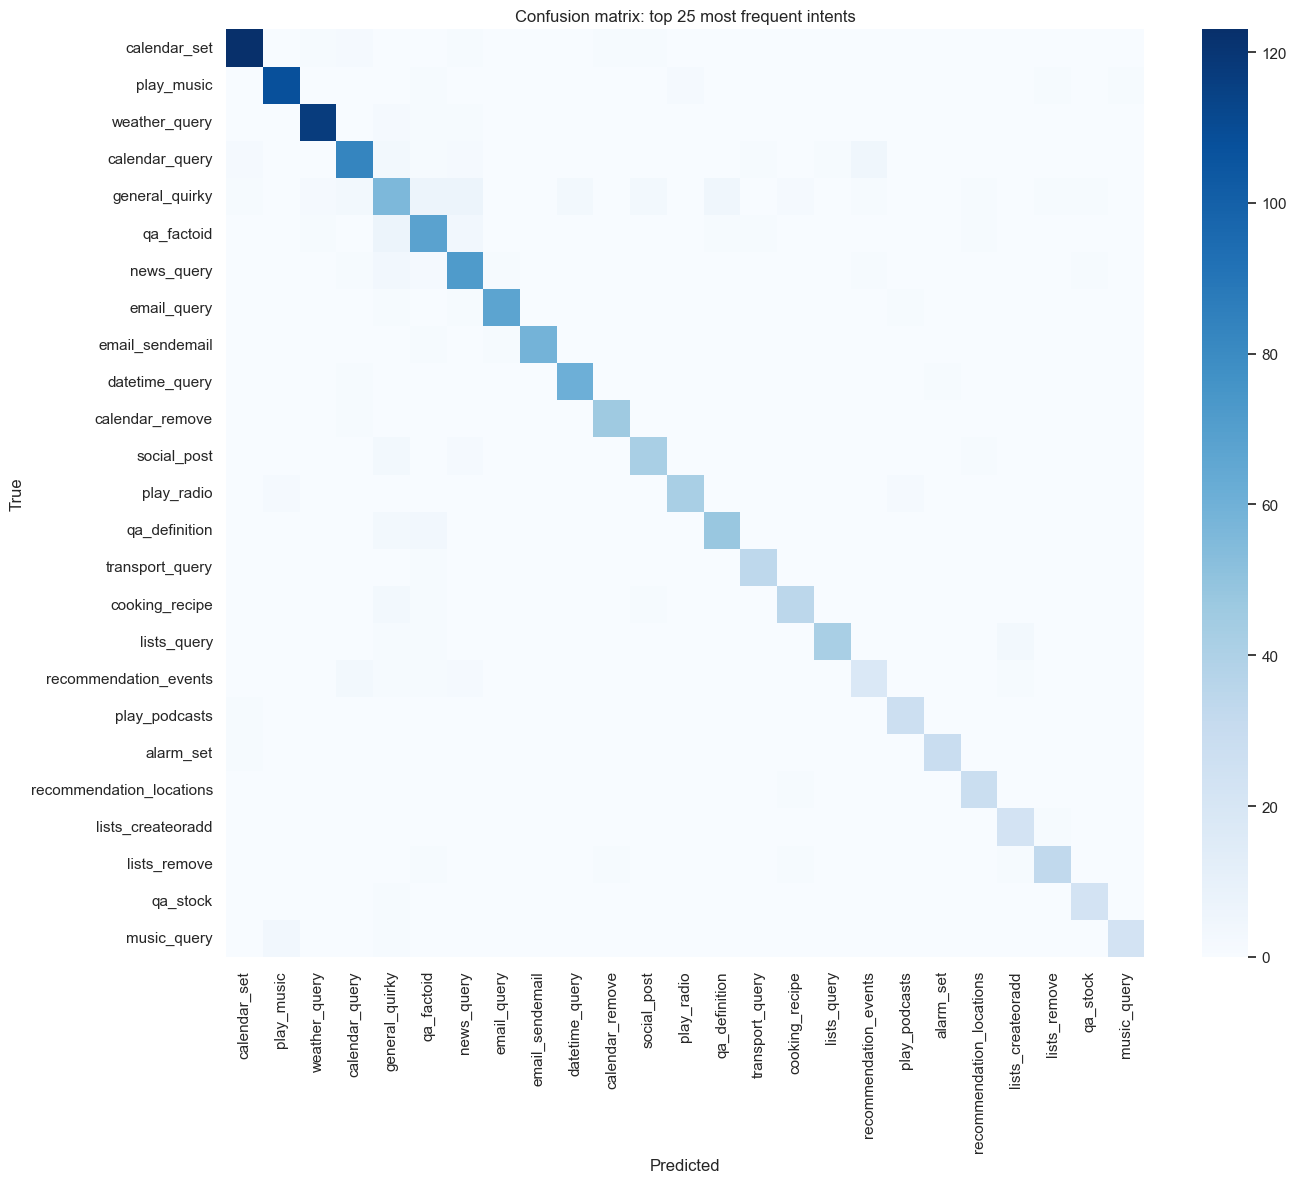

In [27]:
top_intents = train_df["intent"].value_counts().head(25).index.tolist()
top_label_ids = [label2id[i] for i in top_intents]

mask = np.isin(true_labels, top_label_ids)
cm = confusion_matrix(true_labels[mask], pred_labels[mask], labels=top_label_ids)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, xticklabels=top_intents, yticklabels=top_intents,
    cmap="Blues", annot=False, cbar=True,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix: top 25 most frequent intents")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()


In [28]:
mistakes = val_df[~val_df["correct"]]
confused_pairs = (
    mistakes.groupby(["intent", "predicted_intent"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Most common confusions (true -> predicted):")
confused_pairs.head(20)


Most common confusions (true -> predicted):


,intent,predicted_intent,count
55,general_quirky,news_query,7
84,music,play_music,7
58,general_quirky,qa_factoid,7
124,qa_factoid,general_quirky,7
57,general_quirky,qa_definition,5
15,calendar_query,recommendation_events,5
92,music_query,play_music,4
95,news_query,general_quirky,4
164,takeaway_order,takeaway_query,4
123,qa_definition,qa_factoid,4


## Are confused intents actually similar, or is this just model error?

A quick, cheap seed for the planned Error Taxonomy phase: for the top
confused pairs, measure word overlap between their example training
utterances, and compare against random intent pairs. If confused pairs are
consistently more lexically similar than random pairs, that's evidence the
confusion reflects genuine ambiguity in the language, not just a weak
model -- useful context before over-interpreting the confusion matrix.


In [29]:
def avg_word_overlap(sentences_a, sentences_b, n_samples=20):
    import itertools
    scores = []
    for a, b in itertools.islice(itertools.product(sentences_a, sentences_b), n_samples):
        set_a, set_b = set(a.lower().split()), set(b.lower().split())
        if not set_a or not set_b:
            continue
        scores.append(len(set_a & set_b) / len(set_a | set_b))
    return np.mean(scores) if scores else 0.0


overlap_rows = []
for _, row in confused_pairs.head(10).iterrows():
    sents_true = train_df[train_df["intent"] == row["intent"]]["sentence"].tolist()
    sents_pred = train_df[train_df["intent"] == row["predicted_intent"]]["sentence"].tolist()
    overlap_rows.append({
        "intent": row["intent"],
        "predicted_intent": row["predicted_intent"],
        "count": row["count"],
        "word_overlap": avg_word_overlap(sents_true, sents_pred),
    })

confused_overlap_df = pd.DataFrame(overlap_rows)

random_pairs = []
rng = np.random.default_rng(SEED)
random_intents = rng.choice(unique_intents, size=(20, 2), replace=True)
for a, b in random_intents:
    if a == b:
        continue
    sents_a = train_df[train_df["intent"] == a]["sentence"].tolist()
    sents_b = train_df[train_df["intent"] == b]["sentence"].tolist()
    random_pairs.append(avg_word_overlap(sents_a, sents_b))

baseline_overlap = np.mean(random_pairs) if random_pairs else 0.0

print("Word overlap for confused intent pairs:")
print(confused_overlap_df)
print(f"\nAverage word overlap, confused pairs: {confused_overlap_df['word_overlap'].mean():.4f}")
print(f"Average word overlap, random intent pairs: {baseline_overlap:.4f}")


Word overlap for confused intent pairs:
           intent       predicted_intent  count  word_overlap
0  general_quirky             news_query      7      0.039283
1           music             play_music      7      0.154841
2  general_quirky             qa_factoid      7      0.021650
3      qa_factoid         general_quirky      7      0.000000
4  general_quirky          qa_definition      5      0.020501
5  calendar_query  recommendation_events      5      0.032339
6     music_query             play_music      4      0.028980
7      news_query         general_quirky      4      0.000000
8  takeaway_order         takeaway_query      4      0.033742
9   qa_definition             qa_factoid      4      0.095575

Average word overlap, confused pairs: 0.0427
Average word overlap, random intent pairs: 0.0245


## Hidden-representation visualization

t-SNE of the classifier's final hidden state, colored by true intent.
Intents that cluster together in this space are ones the model represents
similarly internally -- a visual complement to the confusion-pairs table
above. Only plotting the same top-25 intents used in the confusion matrix,
since the full ~90-class version would be unreadable as color-coding.


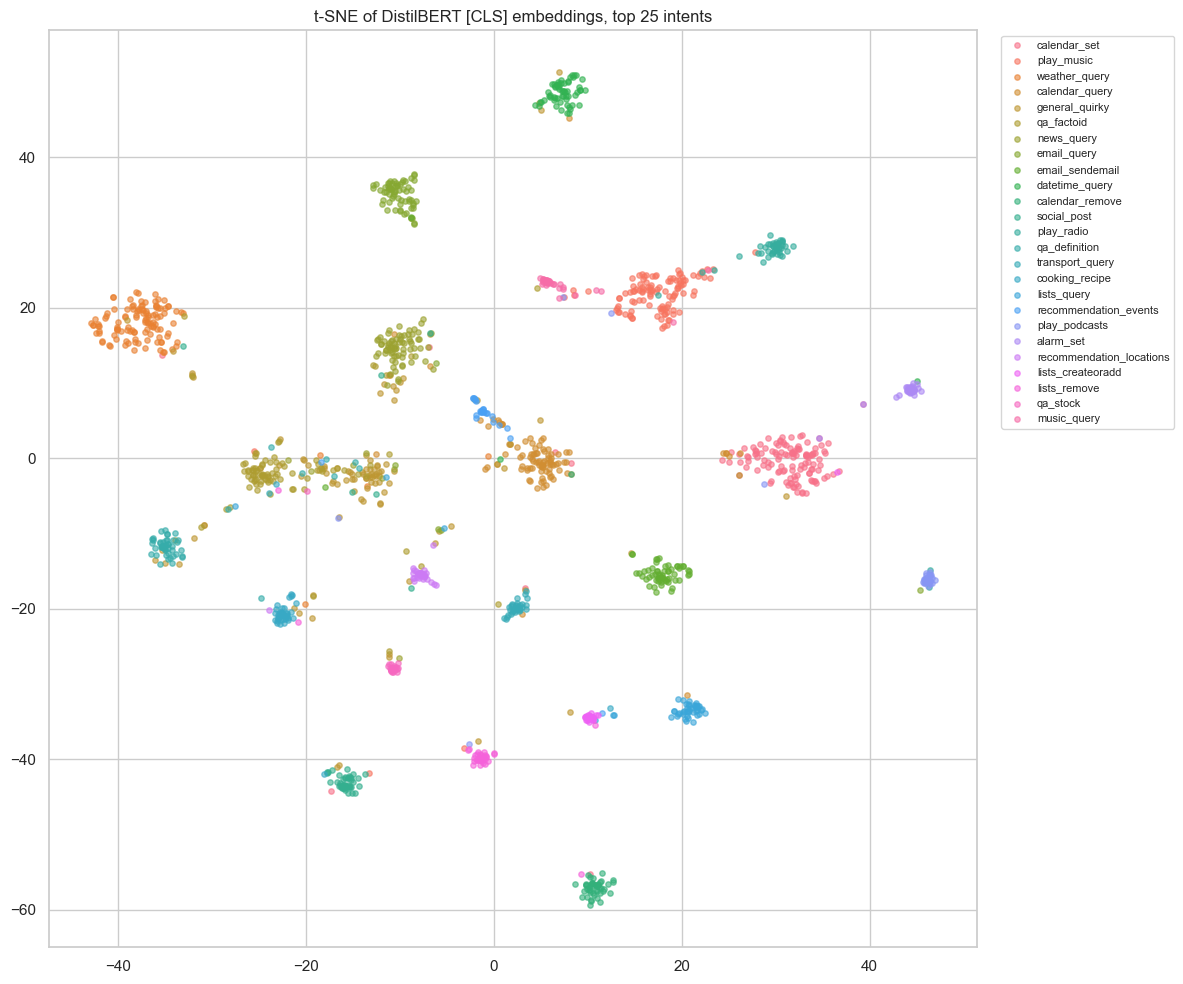

In [30]:
from sklearn.manifold import TSNE

model.eval()
hidden_states = []
with torch.no_grad():
    for i in range(0, len(val_dataset), 64):
        batch = val_dataset[i:i + 64]
        input_ids = torch.tensor(batch["input_ids"]).to(DEVICE)
        attention_mask = torch.tensor(batch["attention_mask"]).to(DEVICE)
        outputs = model.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        hidden_states.append(cls_embedding.cpu().numpy())

hidden_states = np.concatenate(hidden_states, axis=0)

mask = np.isin(true_labels, top_label_ids)
subset_hidden = hidden_states[mask]
subset_labels = [id2label[i] for i in true_labels[mask]]

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
embedded = tsne.fit_transform(subset_hidden)

plt.figure(figsize=(12, 10))
palette = sns.color_palette("husl", len(top_intents))
for i, intent in enumerate(top_intents):
    idx = [j for j, lbl in enumerate(subset_labels) if lbl == intent]
    plt.scatter(embedded[idx, 0], embedded[idx, 1], label=intent, color=palette[i], alpha=0.6, s=15)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.title("t-SNE of DistilBERT [CLS] embeddings, top 25 intents")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "tsne_intent_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()


## Error analysis

Ground truth intent, predicted intent, and the actual sentence, for every
misclassified validation example -- the raw material for spotting
ambiguous phrasing or genuinely similar intents rather than just knowing
the aggregate miss rate.


In [31]:
error_df = mistakes[["sentence", "intent", "predicted_intent"]].rename(
    columns={"intent": "ground_truth_intent"}
)

print(f"{len(error_df)} misclassified out of {len(val_df)} ({len(error_df)/len(val_df)*100:.1f}%)")
error_df.head(20)


268 misclassified out of 2032 (13.2%)


,sentence,ground_truth_intent,predicted_intent
5,the weather updated to the using spb weatherit...,weather_query,news_query
8,which flags ride is the best,recommendation_events,qa_factoid
9,call raju phone number,email_querycontact,transport_taxi
12,when defining words give thesaurus and use in ...,general_quirky,qa_definition
24,what is your mother language,general_quirky,qa_definition
26,play next song,music,play_music
27,when are the trains running tomorrow,calendar_query,transport_query
34,good assistants,news_query,general_quirky
37,lets have a break for five minutes,play_audiobook,general_quirky
41,ask my adviser,qa_stock,general_quirky


In [32]:
print("A few examples from the most common confusion pairs:")
for _, row in confused_pairs.head(5).iterrows():
    examples = mistakes[
        (mistakes["intent"] == row["intent"]) & (mistakes["predicted_intent"] == row["predicted_intent"])
    ]["sentence"].head(3)
    print(f"\n{row['intent']} -> {row['predicted_intent']} ({row['count']} times)")
    for ex in examples:
        print(f"  \"{ex}\"")


A few examples from the most common confusion pairs:

general_quirky -> news_query (7 times)
  "fashion"
  "space research"
  "do you want to hear what have happened today"

music -> play_music (7 times)
  "play next song"
  "play pop"
  "olly put on be warned by tech n9ne"

general_quirky -> qa_factoid (7 times)
  "the cosmos"
  "answer this question what's the first boss in super mario bros"
  "who are the top five all time nhl goal scorers"

qa_factoid -> general_quirky (7 times)
  "none"
  "the following question asks you to analyze teacher goals and actions intended"
  "what is trump's approval rating"

general_quirky -> qa_definition (5 times)
  "when defining words give thesaurus and use in a sentence to make it clearer"
  "what is your mother language"
  "meaning of a particular word"


## Save everything

In [33]:
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(MODEL_OUTPUT_DIR))
tokenizer.save_pretrained(str(MODEL_OUTPUT_DIR))

training_config = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "num_epochs": NUM_EPOCHS,
    "seed": SEED,
    "n_labels": len(label2id),
    "n_train_sentences": len(train_df),
    "n_val_sentences": len(val_df),
    "final_accuracy": final_metrics["eval_accuracy"],
    "final_macro_f1": final_metrics["eval_f1"],
}
with open(MODEL_OUTPUT_DIR / "training_config.json", "w") as f:
    json.dump(training_config, f, indent=2)

val_df.to_csv(REPORTS_DIR / "intent_validation_predictions.csv", index=False)

with open(REPORTS_DIR / "classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)

print(f"Model + tokenizer saved to {MODEL_OUTPUT_DIR}")
print(f"Predictions saved to {REPORTS_DIR / 'intent_validation_predictions.csv'}")
print(f"Classification report saved to {REPORTS_DIR / 'classification_report.json'}")


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.50it/s]

Model + tokenizer saved to c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\distilbert_intent
Predictions saved to c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\intent_validation_predictions.csv
Classification report saved to c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\classification_report.json


## Conclusion

This establishes the intent-classification upper bound — DistilBERT on clean ground-truth transcripts — the ceiling every later ASR-based intent result is measured against. As hypothesized, intent classification on short SLURP commands is far easier than the ASR problem itself.

**Key results**
- Validation accuracy: `0.8681`; macro-F1 `0.7067`; weighted-F1 `0.8608`
- Top-3 accuracy: `0.9483` — an 8.0-point lift over top-1, so most misses are near-misses
- Expected Calibration Error: `0.0541` (reasonably well-calibrated on clean input)
- Misclassified `268 / 2032` (`13.2%`); class-support vs per-class-F1 correlation `0.547`, so rare intents are genuinely harder

**Caveat:** one validation intent (`likeness`) never appears in training and was dropped from scoring; macro-F1 is further depressed by many single-example intents.

**Feeds into:** NB08 reuses this exact model (`models/distilbert_intent/`) plus its saved probabilities (`reports/ground_truth_val_probabilities.npy`) to measure the accuracy/calibration gap that ASR noise introduces — no retraining.